# Empirical Baseline Calibration
This notebook establishes the methodological bounds for the expected scoring ranges used in our benchmark suite. Because the datasets contain Gaussian noise, a maximal correlation of `1.0` is mathematically impossible.

We utilize **Asymptotic Sweeps** across increasing polynomial kernel degrees to determine the empirical ceilings before structural limits or severe overfitting occur.

In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore")

from calibration_sweep import BaselineCalibrator

calibrator = BaselineCalibrator(n_samples=500, n_splits=5)

## 1. Establishing the Noise Floor (The Sine Wave)
Before analyzing structural limits, we must establish the maximum possible score given the 10% injected Gaussian noise. On an ideal topology like the Sine wave, the algorithm effortlessly approaches the perfect correlation (scoring `0.95` to `0.99`, depending on the random noise variance). We use this baseline to mathematically prove when the algorithm is failing to map complex geometry in
later tests.


Running Asymptotic Sweep for: Sine
Sweeping Polynomial Degrees 2 through 10...
Testing Degree 10... Complete!      


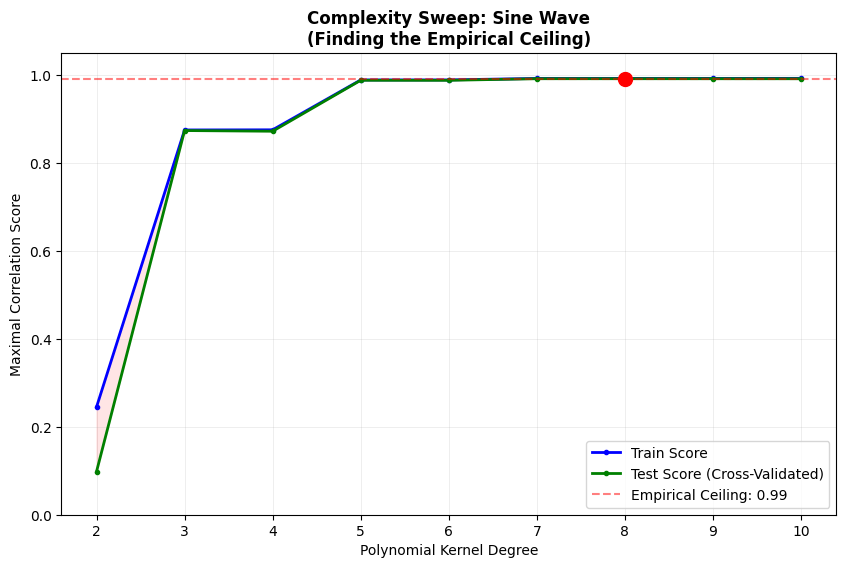

In [2]:
# Run the asymptotic sweep on the Sine dataset
df_sine = calibrator.run_asymptotic_sweep("Sine", max_degree=10)

# Plot the learning curve to prove the noise floor
calibrator.plot_sweep(df_sine, "Sine Wave")

## 2. Finding the Structural Limit (The Swiss Roll)
Because Polynomial Kernels rely on Euclidean dot products, they lack the Geodesic mapping required to unroll 3D manifolds. The complexity sweep empirically proves this limitation: the model hits a severe performance ceiling at `0.84`, significantly below the `0.95+` noise floor. This indicates the kernel is taking a Euclidean cross-section (slicing) through the manifold layers rather than unwinding its true topology.


Running Asymptotic Sweep for: SwissRoll
Sweeping Polynomial Degrees 2 through 12...
Testing Degree 12... Complete!      


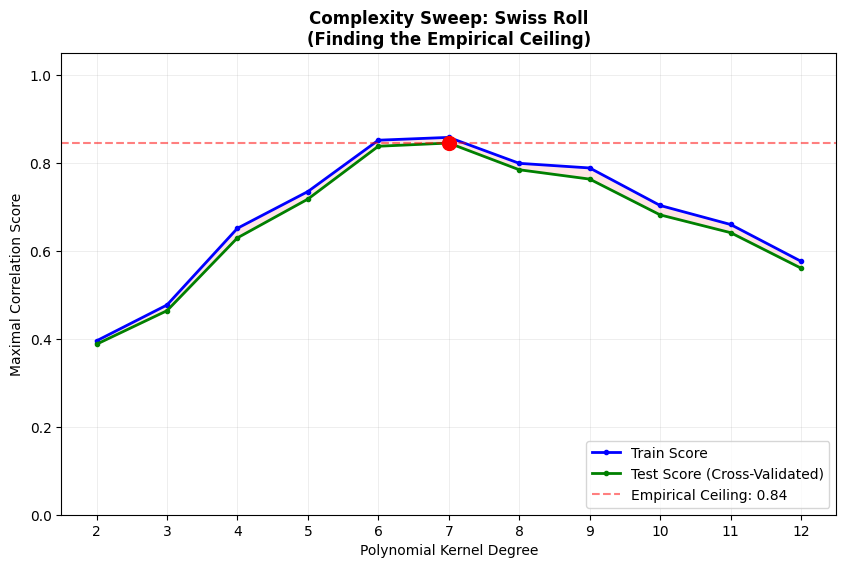

In [3]:
# Run the asymptotic sweep on the Swiss Roll dataset
df_swiss = calibrator.run_asymptotic_sweep("SwissRoll", max_degree=12)

# Plot the learning curve to prove the empirical ceiling
calibrator.plot_sweep(df_swiss, "Swiss Roll")

## 3. Capacity vs. Topology (Moons Dataset)
While global polynomials structurally fail to unroll 3D spirals, they *can* model 2D interlocking geometries like the Moons if the degree is high enough.

However, if the degree is too high, the polynomial will succumb to Runge's Phenomenon and overfit. We sweep the polynomial degree from 2 to 15 to visually identify the exact "sweet spot" where the algorithm weaves through the crescents without memorizing the noise.


Running Asymptotic Sweep for: Moons
Sweeping Polynomial Degrees 2 through 15...
Testing Degree 15... Complete!      


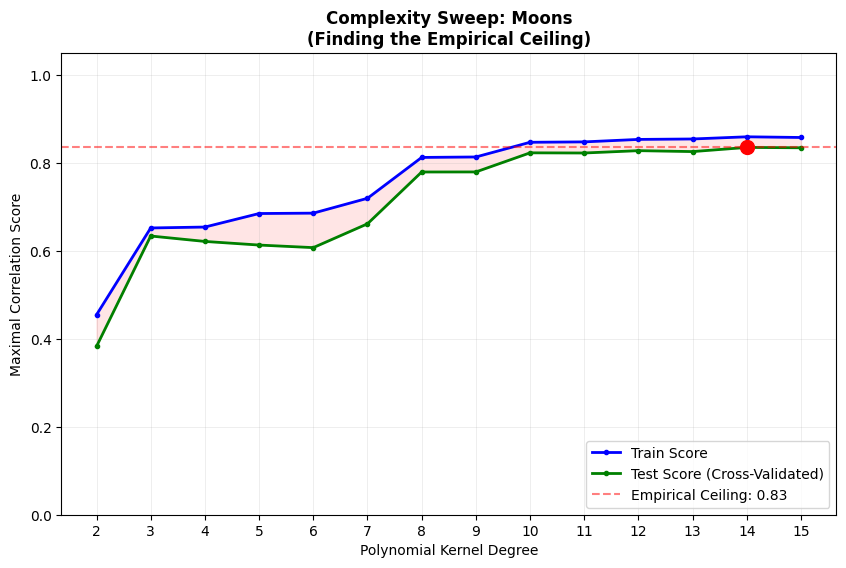

In [4]:
# Run the asymptotic sweep on the Moons dataset
df_moons = calibrator.run_asymptotic_sweep("Moons", max_degree=15)

# Plot the learning curve to find the optimal polynomial degree
calibrator.plot_sweep(df_moons, "Moons")

## 4. Validating the Overfitting Penalty (Independent Noise)
Maximal Correlation algorithms are prone to hallucinating dependencies in pure noise (spurious correlation) if given too much functional capacity.

We run a complexity sweep on two completely independent Gaussian vectors to prove that the cross-validation penalty successfully rejects these
hallucinations, keeping the Test Score near `0.0` even as the Train Score attempts to climb.


Running Asymptotic Sweep for: Independent
Sweeping Polynomial Degrees 2 through 10...
Testing Degree 10... Complete!      


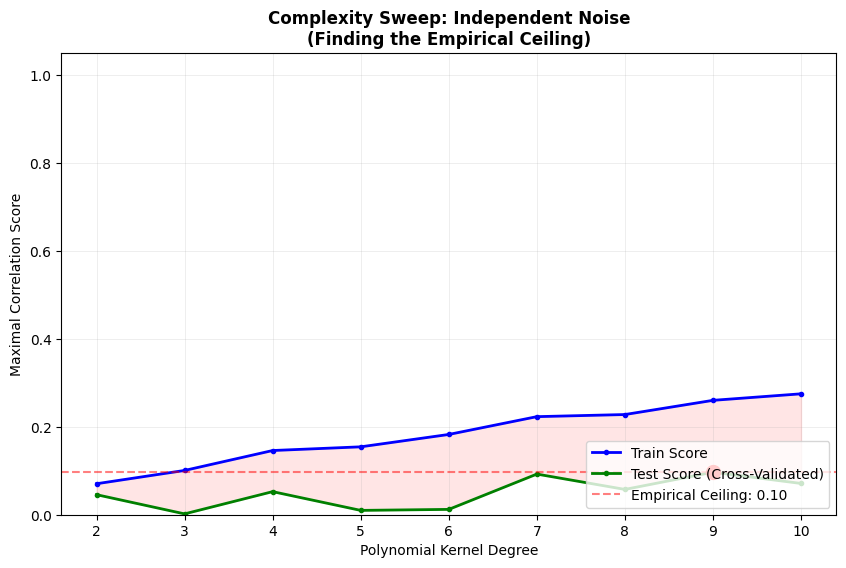

In [5]:
# Run the asymptotic sweep on the Independent Noise dataset
df_indep = calibrator.run_asymptotic_sweep("Independent", max_degree=10)

# Plot the learning curve to prove the cross-validation penalty works
calibrator.plot_sweep(df_indep, "Independent Noise")